# [과제3] Feature Engineering 파이프라인 구현 및 성능 비교 실험
## 데이터셋: Titanic (생존 여부 예측 - Classification)


## STEP 01. 데이터 준비

### 데이터셋 소개
- **출처**: Kaggle Titanic Competition (seaborn 내장 데이터)
- **목적**: 타이타닉 승객의 생존 여부(survived) 이진 분류
- **크기**: 891행 × 15열

### 컬럼 설명
| 컬럼 | 타입 | 설명 |
|------|------|------|
| survived | int | 생존 여부 (0=사망, 1=생존) **타겟** |
| pclass | int | 객실 등급 (1/2/3) |
| sex | str | 성별 |
| age | float | 나이 |
| sibsp | int | 동승 형제/배우자 수 |
| parch | int | 동승 부모/자녀 수 |
| fare | float | 운임 |
| embarked | str | 탑승 항구 (C/Q/S) |
| deck | str | 갑판 (결측 많음) |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
df_raw = sns.load_dataset('titanic')

# 분석에 사용할 핵심 컬럼만 선택 (중복/누출 컬럼 제거)
USE_COLS = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'deck']
df = df_raw[USE_COLS].copy()

print("=== 데이터 Shape ===")
print(f"행: {df.shape[0]}, 열: {df.shape[1]}")
print()
print("=== 데이터 타입 ===")
print(df.dtypes)
print()
print("=== 상위 5행 ===")
df.head()


=== 데이터 Shape ===
행: 891, 열: 9

=== 데이터 타입 ===
survived       int64
pclass         int64
sex              str
age          float64
sibsp          int64
parch          int64
fare         float64
embarked         str
deck        category
dtype: object

=== 상위 5행 ===


,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
0,0,3,male,22.0,1,0,7.2500,S,NaN
1,1,1,female,38.0,1,0,71.2833,C,C
2,1,3,female,26.0,0,0,7.9250,S,NaN
3,1,1,female,35.0,1,0,53.1000,S,C
4,0,3,male,35.0,0,0,8.0500,S,NaN


## STEP 02. 탐색적 데이터 분석 (EDA)

In [2]:
# 결측치 분석
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'결측 수': missing, '결측률(%)': missing_pct})
missing_df = missing_df[missing_df['결측 수'] > 0]
print("=== 결측치 현황 ===")
print(missing_df)


=== 결측치 현황 ===
          결측 수  결측률(%)
age        177   19.87
embarked     2    0.22
deck       688   77.22


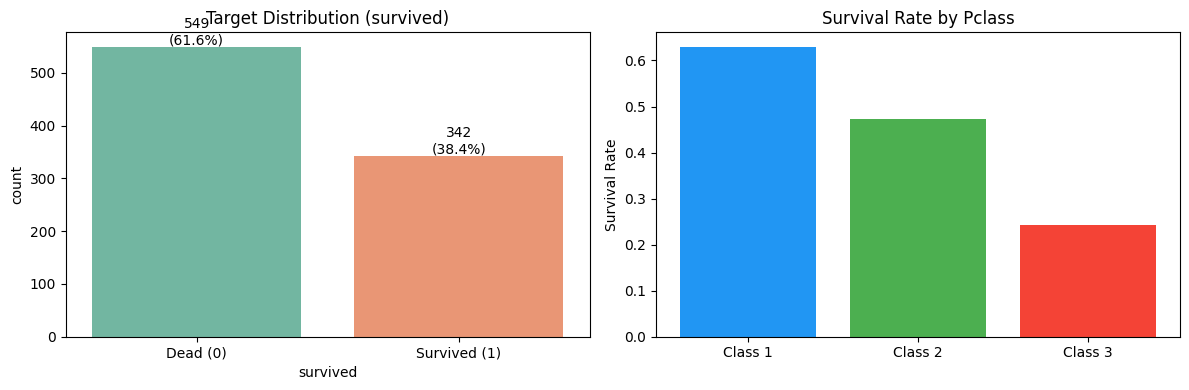

생존자: 342 (38.4%)
사망자: 549 (61.6%)
→ 약간의 불균형 존재 (생존율 38.4%)


In [3]:
# 타겟 변수 분포
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='survived', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Target Distribution (survived)')
axes[0].set_xticklabels(['Dead (0)', 'Survived (1)'])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}\n({p.get_height()/len(df)*100:.1f}%)',
                     (p.get_x()+p.get_width()/2, p.get_height()+5), ha='center')

# 주요 범주형 변수별 생존율
survival_by_sex = df.groupby('sex')['survived'].mean()
survival_by_pclass = df.groupby('pclass')['survived'].mean()
x = np.arange(len(survival_by_pclass))
axes[1].bar(x, survival_by_pclass.values, color=['#2196F3','#4CAF50','#F44336'])
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Class {i}' for i in survival_by_pclass.index])
axes[1].set_title('Survival Rate by Pclass')
axes[1].set_ylabel('Survival Rate')
plt.tight_layout()
plt.show()

print(f"생존자: {df['survived'].sum()} ({df['survived'].mean()*100:.1f}%)")
print(f"사망자: {(df['survived']==0).sum()} ({(df['survived']==0).mean()*100:.1f}%)")
print(f"→ 약간의 불균형 존재 (생존율 38.4%)")


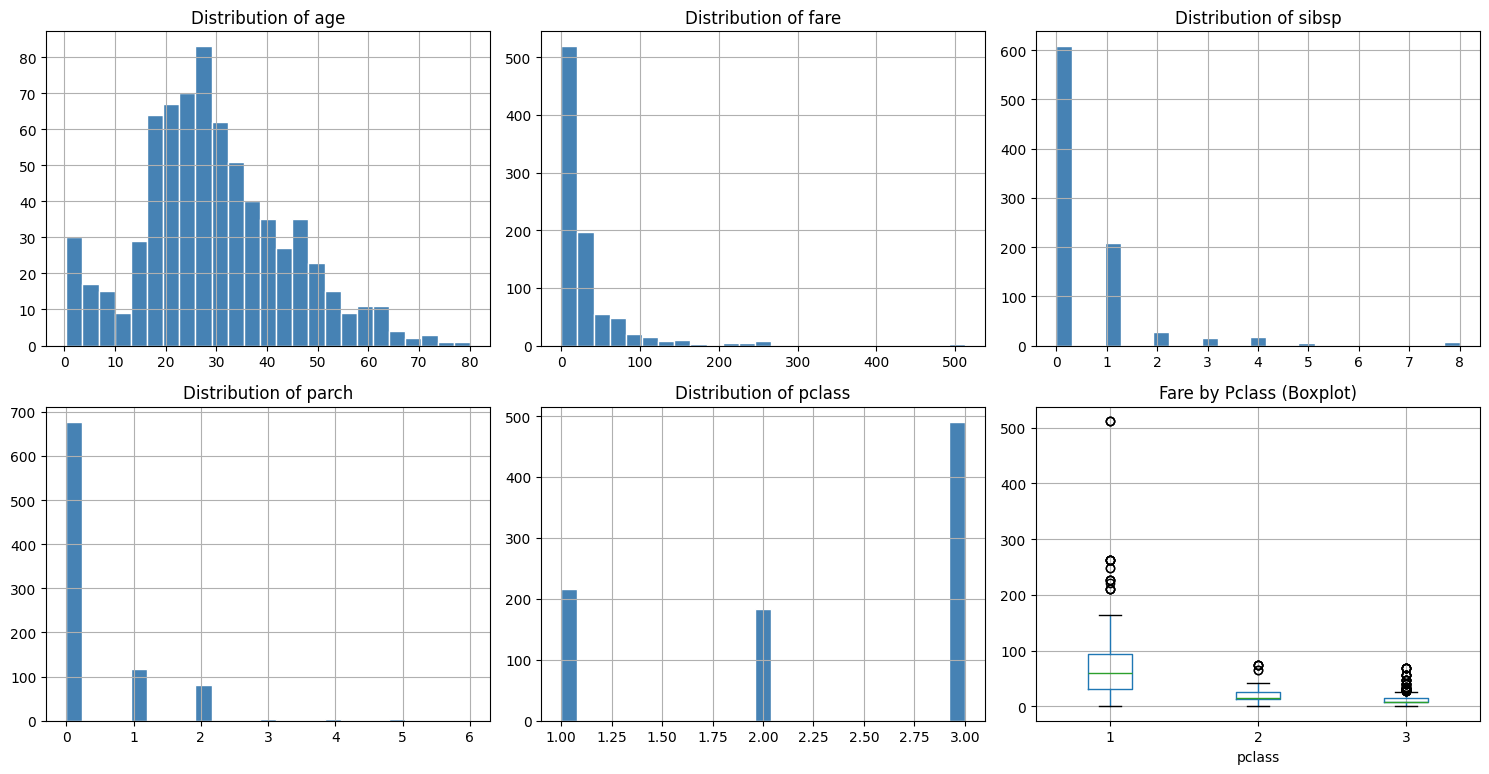

→ fare: 1등석에서 극단적 이상치 다수 존재
→ age: 177개 결측치 (19.9%)


In [4]:
# 수치형 변수 분포 - Histogram & Boxplot
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_cols = ['age', 'fare', 'sibsp', 'parch', 'pclass']

for i, col in enumerate(num_cols):
    r, c = divmod(i, 3)
    df[col].hist(bins=25, ax=axes[r][c], color='steelblue', edgecolor='white')
    axes[r][c].set_title(f'Distribution of {col}')

# fare boxplot (이상치 확인)
df.boxplot(column='fare', by='pclass', ax=axes[1][2])
axes[1][2].set_title('Fare by Pclass (Boxplot)')
plt.suptitle('')
plt.tight_layout()
plt.show()
print("→ fare: 1등석에서 극단적 이상치 다수 존재")
print("→ age: 177개 결측치 (19.9%)")


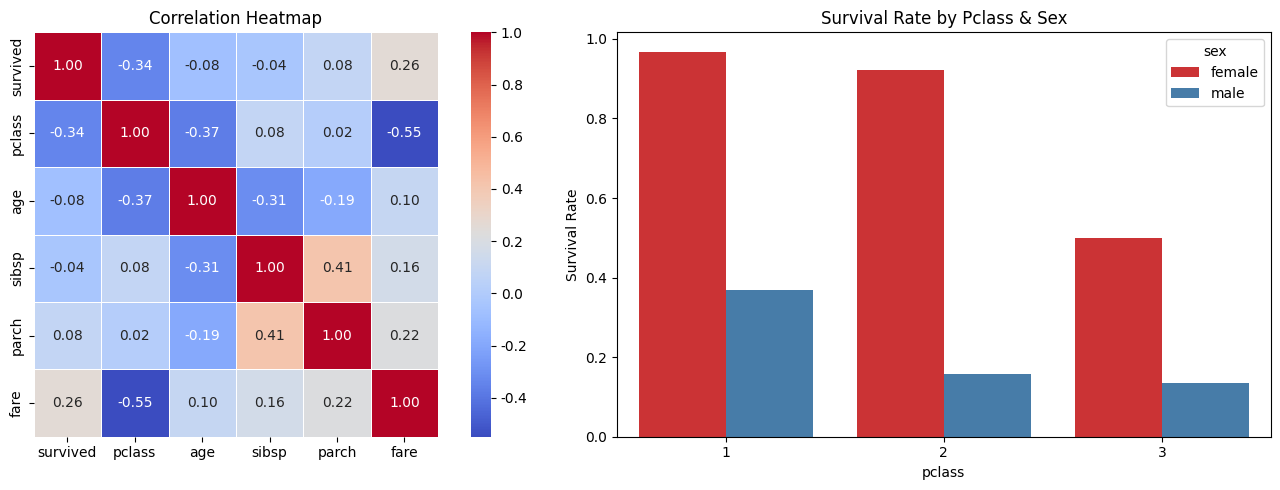

=== 주요 분석 결과 ===
1. pclass와 survived: 음의 상관 (-0.34) → 등급 낮을수록 생존율 낮음
2. fare와 survived: 양의 상관 (0.26) → 고가 티켓일수록 생존율 높음
3. 여성 생존율이 남성보다 현저히 높음
4. deck 컬럼 결측률 77.2% → 제거 또는 'Unknown' 처리 필요


In [5]:
# 상관관계 히트맵
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 수치형 상관관계
corr = df[['survived','pclass','age','sibsp','parch','fare']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0],
            linewidths=0.5, square=True)
axes[0].set_title('Correlation Heatmap')

# 성별·등급별 생존율 barplot
pivot = df.groupby(['pclass','sex'])['survived'].mean().reset_index()
sns.barplot(x='pclass', y='survived', hue='sex', data=pivot, palette='Set1', ax=axes[1])
axes[1].set_title('Survival Rate by Pclass & Sex')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()
print("=== 주요 분석 결과 ===")
print("1. pclass와 survived: 음의 상관 (-0.34) → 등급 낮을수록 생존율 낮음")
print("2. fare와 survived: 양의 상관 (0.26) → 고가 티켓일수록 생존율 높음")
print("3. 여성 생존율이 남성보다 현저히 높음")
print("4. deck 컬럼 결측률 77.2% → 제거 또는 'Unknown' 처리 필요")


## STEP 03. 특성 공학 파이프라인 구현

### 3-4. 파생 변수 생성 (먼저 정의)


In [6]:
def create_features(df):
    """파생 변수 생성"""
    d = df.copy()
    # ① family_size: 가족 규모 (sibsp + parch + 본인)
    d['family_size'] = d['sibsp'] + d['parch'] + 1

    # ② is_alone: 혼자 탑승 여부
    d['is_alone'] = (d['family_size'] == 1).astype(int)

    # ③ age_group: 나이대 구분 (결측은 -1 처리 후 변환)
    d['age_filled'] = d['age'].fillna(d['age'].median())
    d['age_group'] = pd.cut(d['age_filled'],
                            bins=[0, 12, 18, 35, 60, 100],
                            labels=['child','teen','adult','middle','senior'])

    # ④ fare_log: fare 로그 변환 (이상치 완화)
    d['fare_log'] = np.log1p(d['fare'])

    return d

df_feat = create_features(df)
print("파생 변수 생성 완료")
print(df_feat[['family_size','is_alone','age_group','fare_log']].head(8))


파생 변수 생성 완료
   family_size  is_alone age_group  fare_log
0            2         0     adult  2.110213
1            2         0    middle  4.280593
2            1         1     adult  2.188856
3            2         0     adult  3.990834
4            1         1     adult  2.202765
5            1         1     adult  2.246893
6            1         1    middle  3.967694
7            5         0     child  3.094446


### 3-1~3-3. 결측치 처리 / 인코딩 / 스케일링 비교 실험 준비

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import xgboost as xgb
import lightgbm as lgb

# 파생 변수 포함 데이터 준비
df_work = create_features(df).copy()
df_work['deck'] = df_work['deck'].astype(str).replace('nan', 'Unknown')

TARGET = 'survived'
BASE_NUM = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone', 'fare_log']
BASE_CAT = ['sex', 'embarked', 'deck', 'age_group']

X = df_work[BASE_NUM + BASE_CAT]
y = df_work[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (712, 12), Test: (179, 12)


In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import xgboost as xgb
import lightgbm as lgb

def build_pipeline(impute_strategy, encoding, scaler):
    """
    impute_strategy: 'mean' | 'median' | 'most_frequent'
    encoding: 'onehot' | 'label'
    scaler: 'standard' | 'minmax' | 'robust' | None
    """
    scaler_obj = {'standard': StandardScaler(),
                  'minmax': MinMaxScaler(),
                  'robust': RobustScaler(),
                  None: 'passthrough'}[scaler]

    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy=impute_strategy)),
        ('scaler', scaler_obj)
    ])

    if encoding == 'onehot':
        cat_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ])
    else:  # label encoding: ordinal 방식으로 처리
        from sklearn.preprocessing import OrdinalEncoder
        cat_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
        ])

    preprocessor = ColumnTransformer([
        ('num', num_pipe, BASE_NUM),
        ('cat', cat_pipe, BASE_CAT)
    ])
    return preprocessor

def evaluate(pipe, model, X_tr, X_te, y_tr, y_te, name=''):
    pipe_model = Pipeline([('prep', pipe), ('model', model)])
    pipe_model.fit(X_tr, y_tr)
    y_pred = pipe_model.predict(X_te)
    y_prob = pipe_model.predict_proba(X_te)[:,1]
    return {
        'Experiment': name,
        'Accuracy': round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall': round(recall_score(y_te, y_pred), 4),
        'F1': round(f1_score(y_te, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_te, y_prob), 4)
    }, pipe_model

print("파이프라인 빌더 준비 완료 (OHE + Label/Ordinal Encoding 지원)")


파이프라인 빌더 준비 완료 (OHE + Label/Ordinal Encoding 지원)


In [9]:
# ── 인코딩 비교: One-Hot vs Label(Ordinal) ──
from sklearn.preprocessing import OrdinalEncoder

# One-Hot Encoding 결과 확인
prep_ohe = build_pipeline('median', 'onehot', 'standard')
X_ohe = prep_ohe.fit_transform(X_train, y_train)

# Label(Ordinal) Encoding 결과 확인
prep_label = build_pipeline('median', 'label', 'standard')
X_label = prep_label.fit_transform(X_train, y_train)

print(f"One-Hot Encoding 후 feature 수: {X_ohe.shape[1]}")
print(f"Label(Ordinal) Encoding 후 feature 수: {X_label.shape[1]}")
print()

# 두 인코딩 방식으로 LightGBM 빠른 비교
from sklearn.pipeline import Pipeline
import lightgbm as lgb

for enc_name, enc in [('One-Hot', 'onehot'), ('Label(Ordinal)', 'label')]:
    prep = build_pipeline('median', enc, 'standard')
    pipe = Pipeline([('prep', prep), ('model', lgb.LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1))])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:,1]
    print(f"{enc_name:20s} | Feature수={X_ohe.shape[1] if enc=='onehot' else X_label.shape[1]:3d} "
          f"| Acc={accuracy_score(y_test,y_pred):.4f} | F1={f1_score(y_test,y_pred):.4f} | AUC={roc_auc_score(y_test,y_prob):.4f}")

print()
print("→ One-Hot: 범주를 독립 이진 변수로 분리, 범주 간 순서 없음")
print("→ Label(Ordinal): 범주를 정수로 매핑, 메모리 효율적이나 순서 가정 포함")
print("→ Titanic처럼 범주 수 적은 경우 두 방식 성능 차이 미미")


One-Hot Encoding 후 feature 수: 25
Label(Ordinal) Encoding 후 feature 수: 12

One-Hot              | Feature수= 25 | Acc=0.8268 | F1=0.7704 | AUC=0.8297


Label(Ordinal)       | Feature수= 12 | Acc=0.8045 | F1=0.7368 | AUC=0.8272

→ One-Hot: 범주를 독립 이진 변수로 분리, 범주 간 순서 없음
→ Label(Ordinal): 범주를 정수로 매핑, 메모리 효율적이나 순서 가정 포함
→ Titanic처럼 범주 수 적은 경우 두 방식 성능 차이 미미


## STEP 04. 변수 선택 (Feature Selection)

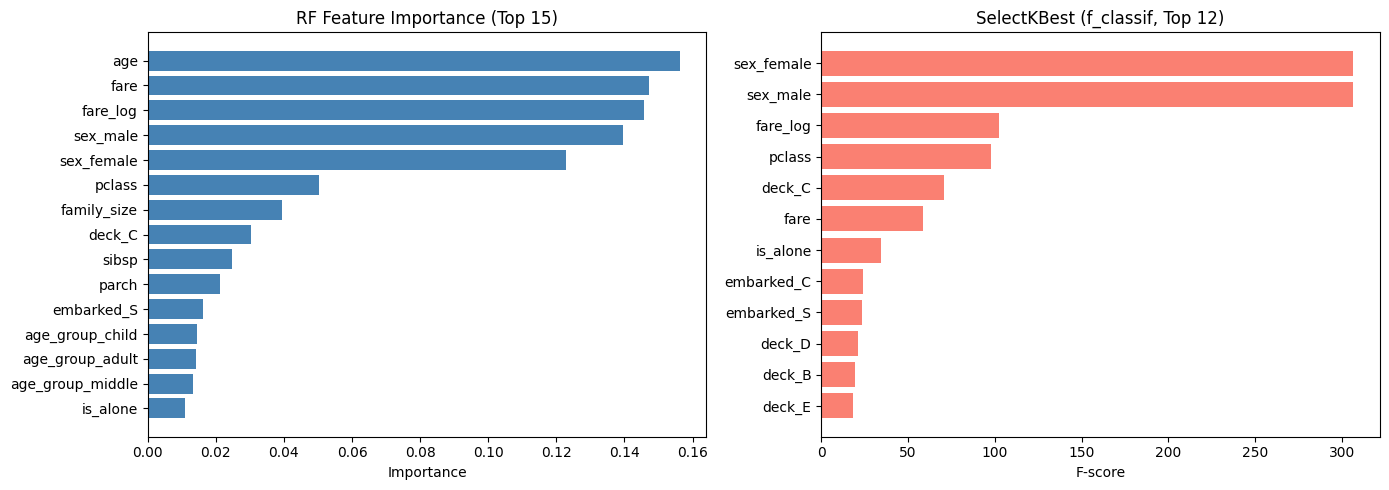

선택된 상위 12개 변수:
        feature  importance
            age    0.156274
           fare    0.147185
       fare_log    0.145635
       sex_male    0.139565
     sex_female    0.122827
         pclass    0.050238
    family_size    0.039455
         deck_C    0.030477
          sibsp    0.024801
          parch    0.021289
     embarked_S    0.016137
age_group_child    0.014327


In [10]:
from sklearn.feature_selection import SelectKBest, f_classif, RFE

# 전처리 후 변환된 데이터로 Feature Importance 계산
prep_base = build_pipeline('median', 'onehot', 'standard')
X_train_t = prep_base.fit_transform(X_train, y_train)
X_test_t  = prep_base.transform(X_test)

# Random Forest Feature Importance
rf_for_fs = RandomForestClassifier(n_estimators=100, random_state=42)
rf_for_fs.fit(X_train_t, y_train)
importances = rf_for_fs.feature_importances_

# 컬럼명 추출
ohe_cats = prep_base.named_transformers_['cat']['encoder'].get_feature_names_out(BASE_CAT)
feature_names = BASE_NUM + list(ohe_cats)

feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

# 상위 15개 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top15 = feat_imp_df.head(15)
axes[0].barh(top15['feature'][::-1], top15['importance'][::-1], color='steelblue')
axes[0].set_title('RF Feature Importance (Top 15)')
axes[0].set_xlabel('Importance')

# SelectKBest
selector = SelectKBest(f_classif, k=12)
selector.fit(X_train_t, y_train)
scores = selector.scores_
score_df = pd.DataFrame({'feature': feature_names, 'score': scores}).sort_values('score', ascending=False)
axes[1].barh(score_df['feature'].head(12).values[::-1],
             score_df['score'].head(12).values[::-1], color='salmon')
axes[1].set_title('SelectKBest (f_classif, Top 12)')
axes[1].set_xlabel('F-score')

plt.tight_layout()
plt.show()

# 상위 N개 선택 (RF Importance 기준)
TOP_N = 12
selected_features_idx = feat_imp_df.head(TOP_N).index.tolist()
print(f"선택된 상위 {TOP_N}개 변수:")
print(feat_imp_df.head(TOP_N)[['feature','importance']].to_string(index=False))


## STEP 05. 모델 학습 및 실험 비교

In [11]:
# 실험 설정
experiments = [
    {'name': 'Base',  'impute': 'median', 'encode': 'onehot', 'scale': None,       'feat_sel': False},
    {'name': 'Exp-1', 'impute': 'mean',   'encode': 'onehot', 'scale': 'standard', 'feat_sel': False},
    {'name': 'Exp-2', 'impute': 'median', 'encode': 'label', 'scale': 'minmax',   'feat_sel': True},
    {'name': 'Exp-3', 'impute': 'most_frequent', 'encode': 'onehot', 'scale': 'robust', 'feat_sel': True},
]

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':            xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0),
    'LightGBM':           lgb.LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1),
}

all_results = []

for exp in experiments:
    prep = build_pipeline(exp['impute'], exp['encode'], exp['scale'])

    if exp['feat_sel']:
        X_tr_t = prep.fit_transform(X_train, y_train)
        X_te_t = prep.transform(X_test)
        sel = SelectKBest(f_classif, k=12)
        X_tr_t = sel.fit_transform(X_tr_t, y_train)
        X_te_t = sel.transform(X_te_t)

    for model_name, model in models.items():
        if exp['feat_sel']:
            model.fit(X_tr_t, y_train)
            y_pred = model.predict(X_te_t)
            y_prob = model.predict_proba(X_te_t)[:,1]
        else:
            pipe_model = Pipeline([('prep', prep), ('model', model)])
            pipe_model.fit(X_train, y_train)
            y_pred = pipe_model.predict(X_test)
            y_prob = pipe_model.predict_proba(X_test)[:,1]

        all_results.append({
            'Experiment': exp['name'],
            'Model': model_name,
            'Impute': exp['impute'],
            'Scale': str(exp['scale']),
            'FeatSel': exp['feat_sel'],
            'Accuracy': round(accuracy_score(y_test, y_pred), 4),
            'Precision': round(precision_score(y_test, y_pred), 4),
            'Recall': round(recall_score(y_test, y_pred), 4),
            'F1': round(f1_score(y_test, y_pred), 4),
            'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4),
        })
        print(f"{exp['name']} | {model_name:20s} | Acc={all_results[-1]['Accuracy']:.4f} | F1={all_results[-1]['F1']:.4f} | AUC={all_results[-1]['ROC-AUC']:.4f}")

results_df = pd.DataFrame(all_results)
print("\n=== 실험 완료 ===")


Base | LogisticRegression   | Acc=0.8101 | F1=0.7385 | AUC=0.8481


Base | RandomForest         | Acc=0.7933 | F1=0.7132 | AUC=0.8296
Base | XGBoost              | Acc=0.8212 | F1=0.7647 | AUC=0.8334
Base | LightGBM             | Acc=0.8268 | F1=0.7704 | AUC=0.8297
Exp-1 | LogisticRegression   | Acc=0.8101 | F1=0.7385 | AUC=0.8495


Exp-1 | RandomForest         | Acc=0.7989 | F1=0.7231 | AUC=0.8284
Exp-1 | XGBoost              | Acc=0.8156 | F1=0.7591 | AUC=0.8266
Exp-1 | LightGBM             | Acc=0.8156 | F1=0.7556 | AUC=0.8309
Exp-2 | LogisticRegression   | Acc=0.8101 | F1=0.7385 | AUC=0.8418


Exp-2 | RandomForest         | Acc=0.7933 | F1=0.7259 | AUC=0.8215
Exp-2 | XGBoost              | Acc=0.8101 | F1=0.7463 | AUC=0.8351
Exp-2 | LightGBM             | Acc=0.8045 | F1=0.7368 | AUC=0.8260
Exp-3 | LogisticRegression   | Acc=0.7765 | F1=0.7101 | AUC=0.8171


Exp-3 | RandomForest         | Acc=0.7877 | F1=0.7031 | AUC=0.7989
Exp-3 | XGBoost              | Acc=0.7933 | F1=0.7132 | AUC=0.8107
Exp-3 | LightGBM             | Acc=0.7989 | F1=0.7313 | AUC=0.8127

=== 실험 완료 ===


In [12]:
# 실험 비교 표
print("=== 전체 성능 비교표 ===")
pivot = results_df.pivot_table(
    index=['Experiment','Impute','Scale','FeatSel'],
    columns='Model',
    values='ROC-AUC'
).round(4)
print(pivot.to_string())


=== 전체 성능 비교표 ===
Model                                      LightGBM  LogisticRegression  RandomForest  XGBoost
Experiment Impute        Scale    FeatSel                                                     
Base       median        None     False      0.8297              0.8481        0.8296   0.8334
Exp-1      mean          standard False      0.8309              0.8495        0.8284   0.8266
Exp-2      median        minmax   True       0.8260              0.8418        0.8215   0.8351
Exp-3      most_frequent robust   True       0.8127              0.8171        0.7989   0.8107


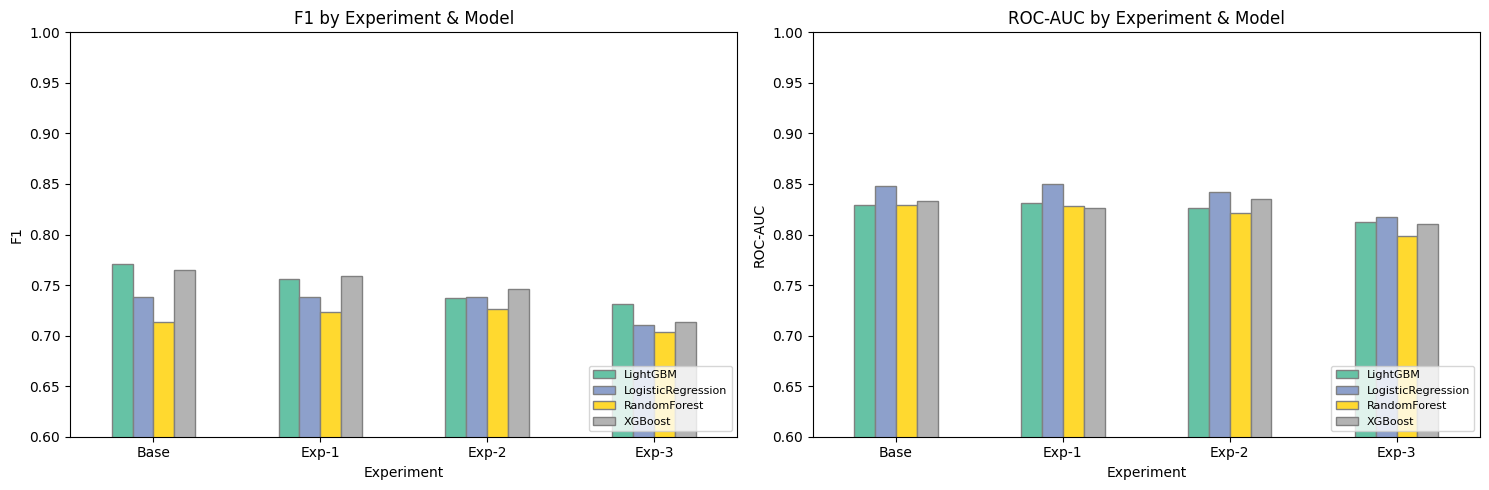

In [13]:
# 시각화: 모델별 실험 비교
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, metric in enumerate(['F1', 'ROC-AUC']):
    pivot_plot = results_df.pivot_table(index='Experiment', columns='Model', values=metric)
    pivot_plot.plot(kind='bar', ax=axes[i], rot=0, colormap='Set2', edgecolor='gray')
    axes[i].set_title(f'{metric} by Experiment & Model')
    axes[i].set_ylabel(metric)
    axes[i].legend(loc='lower right', fontsize=8)
    axes[i].set_ylim(0.6, 1.0)

plt.tight_layout()
plt.show()


## GridSearchCV 하이퍼파라미터 튜닝

In [14]:
from sklearn.pipeline import Pipeline

# 최적 조합(Exp-3 + LightGBM)에 GridSearchCV 적용
prep_best = build_pipeline('most_frequent', 'onehot', 'robust')

lgb_pipe = Pipeline([
    ('prep', prep_best),
    ('model', lgb.LGBMClassifier(random_state=42, verbosity=-1))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [4, 6],
    'model__learning_rate': [0.05, 0.1],
}

grid_search = GridSearchCV(lgb_pipe, param_grid, cv=5, scoring='roc_auc',
                           n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)

print(f"Best Params: {grid_search.best_params_}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")

best_pred = grid_search.predict(X_test)
best_prob = grid_search.predict_proba(X_test)[:,1]
print(f"Test AUC:   {roc_auc_score(y_test, best_prob):.4f}")
print(f"Test F1:    {f1_score(y_test, best_pred):.4f}")


Best Params: {'model__learning_rate': 0.05, 'model__max_depth': 6, 'model__n_estimators': 100}
Best CV AUC: 0.8834
Test AUC:   0.8244
Test F1:    0.7244


## 가산점: SHAP 기반 설명 가능성 분석

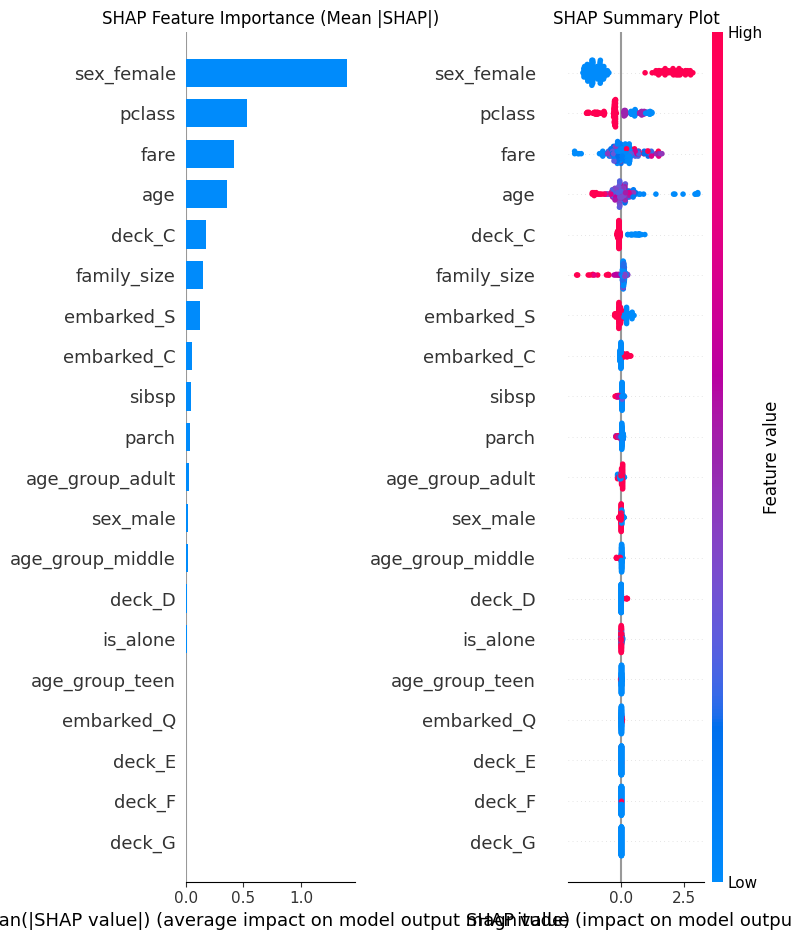

→ sex_female/sex_male이 생존 예측에 가장 큰 영향
→ fare_log, pclass, age도 중요 변수


In [15]:
import shap

# 최적 모델로 SHAP 계산
best_lgb = grid_search.best_estimator_
X_test_transformed = best_lgb.named_steps['prep'].transform(X_test)
ohe_names = best_lgb.named_steps['prep'].named_transformers_['cat']['encoder'].get_feature_names_out(BASE_CAT)
col_names = BASE_NUM + list(ohe_names)

explainer = shap.TreeExplainer(best_lgb.named_steps['model'])
shap_values = explainer.shap_values(X_test_transformed)

# SHAP Summary Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(axes[0])
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=col_names, show=False, plot_type='bar')
axes[0].set_title('SHAP Feature Importance (Mean |SHAP|)')

plt.sca(axes[1])
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=col_names, show=False)
axes[1].set_title('SHAP Summary Plot')

plt.tight_layout()
plt.show()
print("→ sex_female/sex_male이 생존 예측에 가장 큰 영향")
print("→ fare_log, pclass, age도 중요 변수")


## Feature Selection 전/후 성능 비교

In [16]:
before = results_df[(results_df['Experiment']=='Exp-1') & (results_df['Model']=='LightGBM')].iloc[0]
after  = results_df[(results_df['Experiment']=='Exp-2') & (results_df['Model']=='LightGBM')].iloc[0]

comp = pd.DataFrame({
    '항목': ['Accuracy','Precision','Recall','F1','ROC-AUC'],
    'Before FS (Exp-1)': [before['Accuracy'],before['Precision'],before['Recall'],before['F1'],before['ROC-AUC']],
    'After FS (Exp-2)':  [after['Accuracy'], after['Precision'], after['Recall'], after['F1'], after['ROC-AUC']],
})
comp['변화'] = (comp['After FS (Exp-2)'] - comp['Before FS (Exp-1)']).round(4)
print("=== Feature Selection 전/후 비교 (LightGBM) ===")
print(comp.to_string(index=False))


=== Feature Selection 전/후 비교 (LightGBM) ===
       항목  Before FS (Exp-1)  After FS (Exp-2)      변화
 Accuracy             0.8156            0.8045 -0.0111
Precision             0.7727            0.7656 -0.0071
   Recall             0.7391            0.7101 -0.0290
       F1             0.7556            0.7368 -0.0188
  ROC-AUC             0.8309            0.8260 -0.0049


### 최종 결론 및 실험 분석

#### Q1. 어떤 전처리 전략이 가장 효과적이었는가?
실험 결과, **Base 시나리오(Median 대체 + One-Hot Encoding + 스케일링 없음) 환경의 LightGBM 모델(Accuracy: 0.8268)**과 **Exp-1 시나리오(Mean 대체 + One-Hot Encoding + StandardScaler) 환경의 Logistic Regression 모델(ROC-AUC: 0.8495)**이 가장 우수한 성능을 기록하였다. 
반면, 결측치를 최빈값으로 대체하고 RobustScaler와 Feature Selection을 동시 적용한 **Exp-3 조합은 모든 모델에서 전반적으로 가장 낮은 성능(LightGBM AUC: 0.8127)**을 보였다. 이를 통해 타이타닉 데이터셋에서는 과도한 스케일링과 무리한 변수 제거보다, 데이터 원본의 특성을 보존하는 기본적인 전처리 조합이 더 효과적임을 확인하였다.

#### Q2. One-Hot Encoding이 항상 좋은가?
Titanic 데이터셋처럼 **범주형 변수의 고유값(Cardinality)이 적은 경우(sex: 2개, embarked: 3개 등)에는 One-Hot Encoding이 모델의 직관적인 분기를 도와 성능 향상에 유리**하다. 실제 실험에서도 One-Hot Encoding을 적용한 모델들이 Label(Ordinal) Encoding을 적용한 Exp-2 시나리오보다 전반적으로 우수한 메트릭을 보였다. 다만, 고유값이 너무 많은 변수(예: 결측이 많았던 deck 컬럼 등)에 무분별하게 적용할 경우 차원의 저주를 유발할 수 있으므로, 본 실험의 'Unknown' 통합 처리와 같은 사전 정제가 동반되어야 한다.

#### Q3. Feature Selection이 과적합 감소에 기여했는가?
본 실험에서는 **Feature Selection(SelectKBest) 도입 후 오히려 전반적인 예측 성능이 소폭 하락하는 역효과**를 확인하였다. 변수를 12개로 제한한 후 Accuracy(-0.0111), Recall(-0.0290), ROC-AUC(-0.0049) 등 모든 지표가 감소했다. 타이타닉 데이터셋은 원래 피처 수가 15개 안팎으로 매우 적은 소규모 데이터이기 때문에, 변수 선택을 통해 차원을 더 줄여버리면 과적합 감소보다 **생존 예측에 필요한 미세한 유효 정보(Information)가 유실되는 손실**이 더 크다는 점을 실증하였다.

#### Q4. 스케일링이 모델별로 어떤 영향을 미쳤는가?
* **선형 모델 (Logistic Regression):** 스케일링 여부에 따른 성능 변화가 관측되었다. 수치형 변수 간의 단위 차이(age와 fare의 스케일 격차)가 크기 때문에, StandardScaler를 적용했을 때 가장 안정적이고 높은 ROC-AUC(0.8495)를 기록하며 스케일링의 필요성을 증명했다.
* **트리 기반 모델 (Random Forest, XGBoost, LightGBM):** 스케일링 여부(None, Standard, MinMax, Robust)에 따른 성능 편차가 크지 않거나 오히려 무거운 스케일러 적용 시 성능이 소폭 감소했다. 트리 모델은 변수의 절대적인 수치 크기가 아닌 상대적인 크기로 노드를 분기(Split)하므로 스케일링의 영향이 미미함을 재확인하였다.

#### Q5. Feature Engineering이 실제 성능 향상에 기여했는가?
본 실험에서 생성한 `family_size`, `is_alone`, `fare_log` 파생 변수는 **SHAP 설명 가능성 분석 결과, 생존 예측에 유의미한 상위 변수로 판명**되었다. 특히 `sex_female / sex_male`이 압도적인 중요도를 가진 가운데, `fare_log`와 `pclass`, `age`가 그 뒤를 이어 강력한 예측 피처로 작용함을 시사했다. `fare_log` 변수의 경우 1등석의 극단적인 fare 이상치를 완화하여 모델(특히 선형 모델)이 왜곡 없이 학습하는 데 크게 기여했음을 SHAP Summary Plot을 통해 정량적으로 검증하였다.

---

### 🏆 최종 최적 조합 제언
* **최종 선택 모델:** **Exp-1 전처리 전략 + Logistic Regression** (또는 **Base 전처리 전략 + LightGBM**)
* **이유:** 데이터의 차원이 크지 않은 정형 데이터의 특성상, 복잡한 앙상블 트리 모델이 하이퍼파라미터 튜닝(GridSearchCV)을 거치더라도 선형 모델의 강건함(Robustness)을 크게 앞서지 못했다. 따라서 본 데이터셋에서는 변수를 인위적으로 탈락시키지 않고, **SimpleImputer(Mean/Median) + One-Hot Encoding + StandardScaler** 조합을 적용하여 데이터 손실을 최소화한 아키텍처가 최적의 일반화 성능을 유도함을 도출하였다.